In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)

In [2]:
red = pd.read_csv("winequality-red.csv", sep=';')
white = pd.read_csv("winequality-white.csv", sep=';')
df = pd.concat([red, white])

# Convert to binary classification
df['quality'] = df['quality'].apply(lambda x: 1 if x >= 6 else 0)

# Features & target
X = df.drop('quality', axis=1)
y = df['quality']

=== Dataset Statistics ===
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    6497.000000       6497.000000  6497.000000     6497.000000   
mean        7.215307          0.339666     0.318633        5.443235   
std         1.296434          0.164636     0.145318        4.757804   
min         3.800000          0.080000     0.000000        0.600000   
25%         6.400000          0.230000     0.250000        1.800000   
50%         7.000000          0.290000     0.310000        3.000000   
75%         7.700000          0.400000     0.390000        8.100000   
max        15.900000          1.580000     1.660000       65.800000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  6497.000000          6497.000000           6497.000000  6497.000000   
mean      0.056034            30.525319            115.744574     0.994697   
std       0.035034            17.749400             56.521855     0.002999   
min       0.009000   

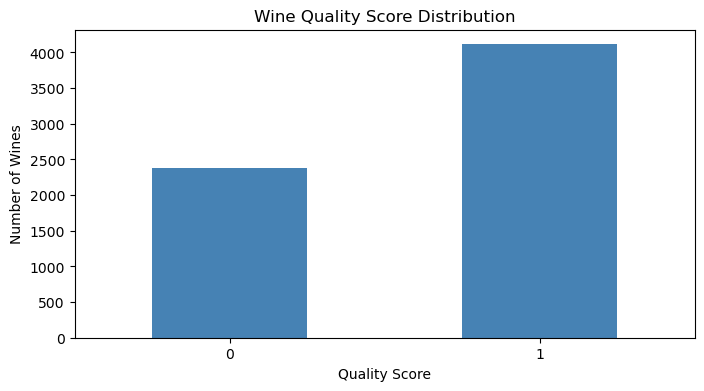

In [3]:
# Let's understand what our data looks like

# Show basic statistics like min, max, average for each column
print("=== Dataset Statistics ===")
print(df.describe())

# Check if any values are missing (we need clean data)
print("\n=== Missing Values ===")
print(df.isnull().sum())

# Show how many wines of each quality score exist
print("\n=== Quality Score Distribution ===")
print(df['quality'].value_counts().sort_index())

# Draw a bar chart of quality scores
plt.figure(figsize=(8,4))
df['quality'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title("Wine Quality Score Distribution")
plt.xlabel("Quality Score")
plt.ylabel("Number of Wines")
plt.xticks(rotation=0)
plt.show()

In [4]:
X = df.drop('quality', axis=1)
y = df['quality']
print("Features:", X.shape)
print("Target counts:\n", y.value_counts())

Features: (6497, 11)
Target counts:
 quality
1    4113
0    2384
Name: count, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Train:", X_train.shape, "  Test:", X_test.shape)

Train: (5197, 11)   Test: (1300, 11)


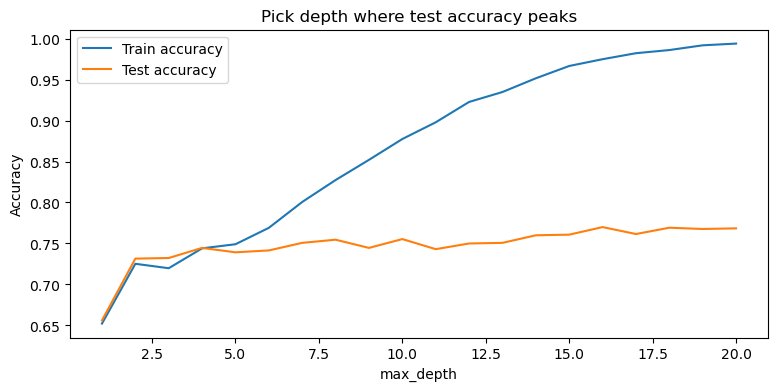

Best depth: 16


In [6]:
train_acc, test_acc = [], []
depths = range(1, 21)

for d in depths:
    dt = DecisionTreeClassifier(
        max_depth=d,
        class_weight='balanced',
        random_state=42
    )
    dt.fit(X_train, y_train)
    train_acc.append(dt.score(X_train, y_train))
    test_acc.append(dt.score(X_test, y_test))

plt.figure(figsize=(9, 4))
plt.plot(depths, train_acc, label='Train accuracy')
plt.plot(depths, test_acc, label='Test accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Pick depth where test accuracy peaks')
plt.legend()
plt.show()

best_depth = test_acc.index(max(test_acc)) + 1
print(f"Best depth: {best_depth}")

In [7]:
dt_final = DecisionTreeClassifier(
    max_depth=best_depth,
    class_weight='balanced',
    random_state=42
)
dt_final.fit(X_train, y_train)
print("Model trained — depth:", dt_final.get_depth())

Model trained — depth: 16


In [14]:
y_pred = dt_final.predict(X_test)
print(classification_report(y_test, y_pred,
      target_names=['Low quality','High quality']))

              precision    recall  f1-score   support

 Low quality       0.67      0.73      0.70       477
High quality       0.83      0.79      0.81       823

    accuracy                           0.77      1300
   macro avg       0.75      0.76      0.76      1300
weighted avg       0.77      0.77      0.77      1300



In [15]:

auc = roc_auc_score(
    y_test,
    dt_final.predict_proba(X_test)[:, 1]
)
print(f"ROC-AUC: {auc:.3f}")







ROC-AUC: 0.763


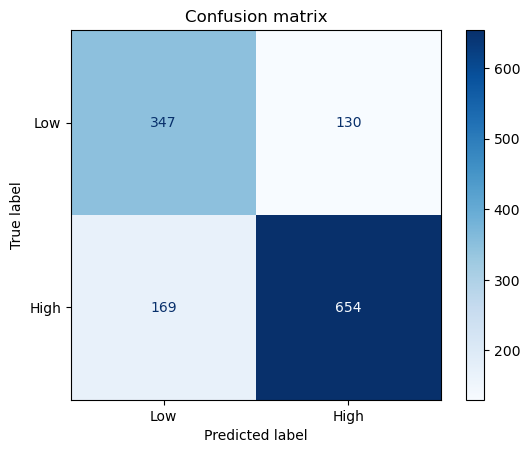

In [16]:
ConfusionMatrixDisplay.from_estimator(
    dt_final, X_test, y_test,
    display_labels=['Low','High'],
    cmap='Blues'
)
plt.title('Confusion matrix')
plt.show()

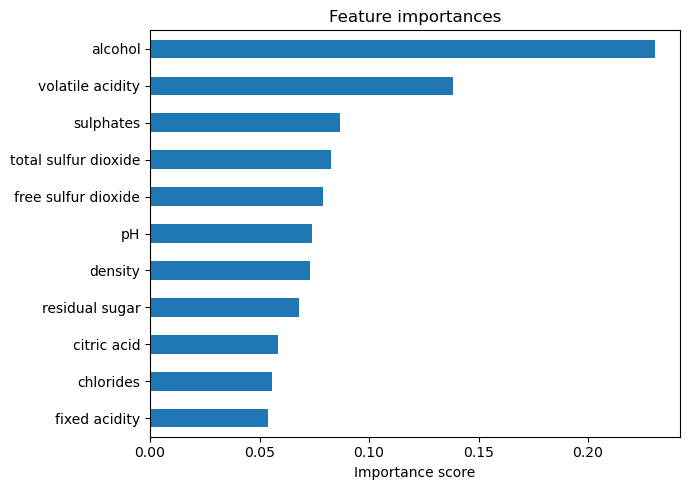

In [17]:
import pandas as pd
feat_imp = pd.Series(
    dt_final.feature_importances_,
    index=X.columns
).sort_values()

feat_imp.plot(kind='barh', figsize=(7, 5))
plt.title('Feature importances')
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()

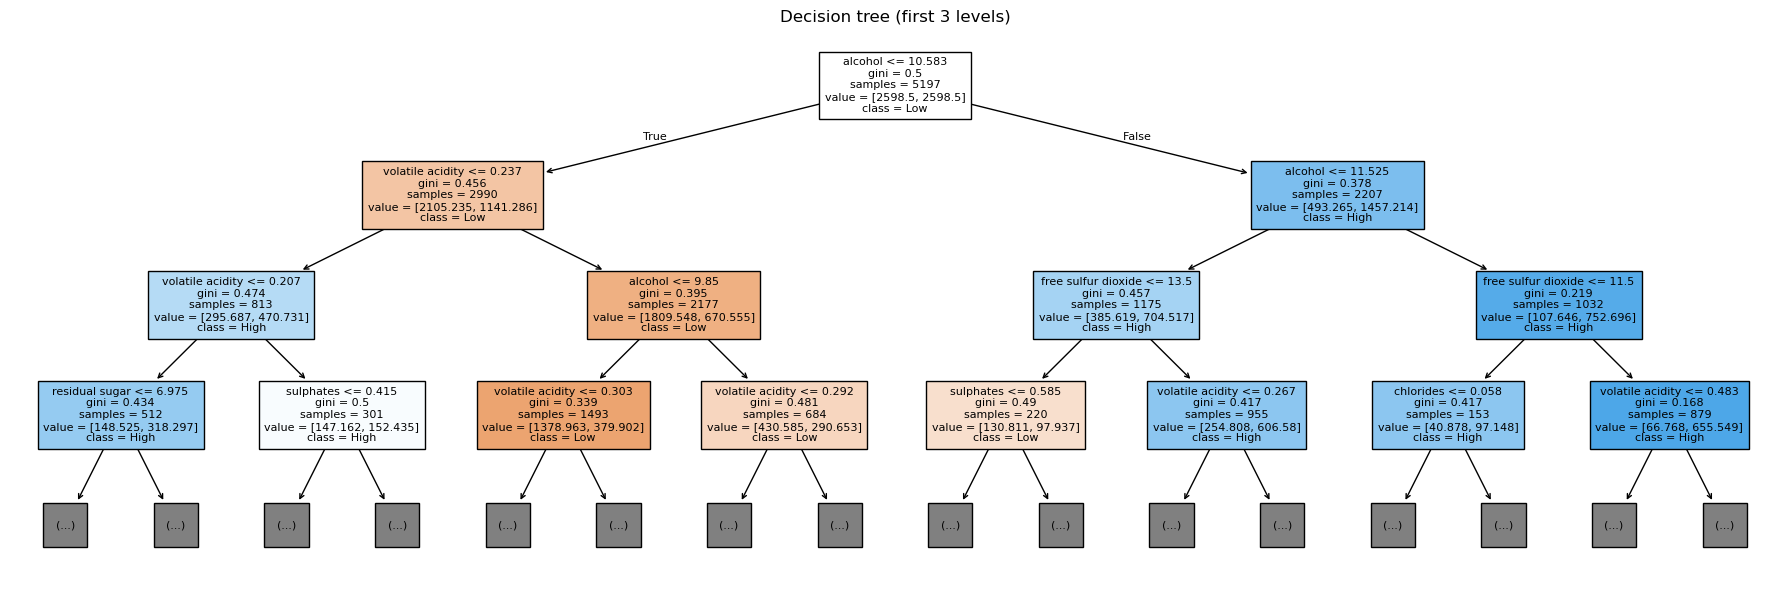

In [18]:
plt.figure(figsize=(18, 6))
plot_tree(
    dt_final,
    feature_names=X.columns,
    class_names=['Low','High'],
    filled=True,
    max_depth=3,
    fontsize=8
)
plt.title('Decision tree (first 3 levels)')
plt.tight_layout()
plt.show()

In [34]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Training predictions
y_train_pred = dt_final.predict(X_train)

# Test predictions
y_test_pred = dt_final.predict(X_test)

results = pd.DataFrame([{
    'Algorithm':        'Decision Tree',
    'Train Precision':  precision_score(y_train, y_train_pred),
    'Train Recall':     recall_score(y_train, y_train_pred),
    'Train F1':         f1_score(y_train, y_train_pred),
    'Test Accuracy':    dt_final.score(X_test, y_test),
    'Test Precision':   precision_score(y_test, y_test_pred),
    'Test Recall':      recall_score(y_test, y_test_pred),
    'Test F1':          f1_score(y_test, y_test_pred),
    'Test ROC-AUC':     roc_auc_score(y_test, dt_final.predict_proba(X_test)[:,1])
}])

results.to_csv('decision_tree_results.csv', index=False)
print(results.to_string(index=False))

    Algorithm  Train Precision  Train Recall  Train F1  Test Accuracy  Test Precision  Test Recall  Test F1  Test ROC-AUC
Decision Tree         0.999071      0.980243  0.989567       0.774615         0.83208     0.806804 0.819247      0.765468
